In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [7]:
def centre_of_neighbours(positions_array):
    '''
    for each fish at each time step finding the mean
    position for all other visible (not nan) fish - the centre of the nighbours
    '''
    t, n, _ = positions_array.shape # t = timesteps, n = number of fish
    centres = np.full((t, n, 2), np.nan) # pre fill with NaN values so that if the centre cannot be calculated there will still be a NaN value in the array
    n_neighbours = np.zeros((t, n), dtype=int) # creating an empty count array to fill in the loop

    for f in range(n):
        # getting indicies of every fish expect fish f that is the one we are looping over
        otherfish_idx = [j for j in range(n) if j != f]
        otherfish = positions_array[:, otherfish_idx, :] # positions of all other fish

        # finding mean of all neihgbouring fish whilst ignoring the NaN values
        with np.errstate(all='ignore'): # suppressing warnings from all NaN slices
            centres[:, f, :] = np.nanmean(otherfish, axis=1)

        # counting how many neighbours are visible (not NaN) at each timestep
        visible_fish = ~np.isnan(otherfish[:, :, 0])
        n_neighbours[:, f] = visible_fish.sum(axis=1)

    return centres, n_neighbours

def loading_all_experiments(folder, n_fish):
    ''' 
    finding all the CSV files in the given folder and loading all the data
    '''
    files = sorted(glob.glob(f'{folder}/*.csv'))
    print(f'found {len(files)} files in {folder}')

    dataframes = []
    for f in files:
        df = pd.read_csv(f)
        df['source_file'] = f # tagging each row so I know which file it came from
        dataframes.append(df)

    return dataframes # returns a list of dataframes - one per CSV file

def remove_outliers(cohesion_distance_cm, threshold_multiplier=3):
    ''' 
    removing the high outlier data so there are no spikes when it is plotted
    cohesion_distnace_cm = array of shape (timesteps, n_fish)
    threshold_multiplier = how many standard deviations count as a spike
    '''
    cleaned = cohesion_distance_cm.copy() # creating a copy of the origional array

    for f in range(cohesion_distance_cm.shape[1]):
        series = cohesion_distance_cm[:, f] # cohesional values for each fish over time

        # using the median and std to define what counts as a spike
        global_median = np.nanmedian(series) # median of all fish' cohesion distnaces across all the data
        global_std = np.nanstd(series) # std of all fish' cohesion distnaces across all the data

        # flagging any values more that 3 stds away from the median
        is_spike = np.abs(series - global_median) > (threshold_multiplier * global_std)

        # reporting how many frames were removed for this said fish f
        n_spikes = is_spike.sum()
        pct = n_spikes / len(series) * 100
        print(f'fish{f+1}: {n_spikes} spike frames removed({pct}% of data)')

        cleaned[is_spike, f] = np.nan # replcing the spiked with NaN

    return cleaned

def finding_cohesion(df, n_fish):
    ''' 
    finding cohesion distnace at each time step - smaller distance 
    = group is swimming more closely together
    '''
    # extracts only the x and y columns for all fish
    columns = [f'X{i}' for i in range(1, n_fish+1)] + [f'Y{i}' for i in range(1, n_fish+1)]
    df_clean = df[columns].dropna() # droping aany rows where there are NaNs

    # building a dictionary of position arrays per fish
    positions = {}
    for i in range(1, n_fish+1):
        positions[i] = df_clean[[f'X{i}', f'Y{i}']].values

    # stack the positions into a sign array shape (timesteps, n_fish, 2)
    local_positions_array = np.stack([positions[i] for i in range(1, n_fish+1)], axis=1)

    local_centres, _ = centre_of_neighbours(local_positions_array) # finding the centre points of the neighbours

    cohesion_vector = local_centres - local_positions_array # cohesion vector
    cohesion_distance_mm = np.linalg.norm(cohesion_vector, axis=2) # cohesion distance

    mean_per_fish = np.array([np.nanmean(cohesion_distance_mm[:, f]) for f in range(n_fish)])
    overall_mean = np.nanmean(cohesion_distance_mm)

    return cohesion_distance_mm, mean_per_fish, overall_mean

In [10]:
# loading all CSV files from the 2 fish and 5 fish data
dataframes_2fish = loading_all_experiments('../data/2', n_fish=2)
dataframes_5fish = loading_all_experiments('../data/5', n_fish=5)

# running finding_cohesion on every experiement for all files 
results_2fish = [finding_cohesion(df, n_fish=2) for df in dataframes_2fish]
results_5fish = [finding_cohesion(df, n_fish=5) for df in dataframes_5fish]

# converting cohesion distances from mm to cm
mm_to_cm = 0.1
cd_2_cm_all = [results_2fish[i][0] * mm_to_cm for i in range(len(results_2fish))]
cd_5_cm_all = [results_5fish[i][0] * mm_to_cm for i in range(len(results_5fish))]

# finding mean cohesion distance for experiments
mean_2fish_all = [np.nanmean(cd) for cd in cd_2_cm_all]
mean_5fish_all = [np.nanmean(cd) for cd in cd_5_cm_all]

# finding overall mean cohesion distance
mean_all_2fish = np.mean(mean_2fish_all) 
mean_all_5fish = np.mean(mean_5fish_all)

cd_2_cm = cd_2_cm_all[1] # using file 2
cd_5_cm = cd_5_cm_all[0] # using file 1

# removing the outliers from my chosen experiments
cd_2_clean_exp2 = remove_outliers(cd_2_cm)
cd_5_clean_exp1 = remove_outliers(cd_5_cm)

# finding the mean cohesion distance from those experiments without the outliers
mean_2fish_clean_exp2 = np.nanmean(cd_2_clean_exp2)
mean_5fish_clean_exp1 = np.nanmean(cd_5_clean_exp1)

print(f'mean for all files for 2 fish = {mean_all_2fish} cm')
print(f'mean for all files for 5 fish = {mean_all_5fish} cm')

print(f'mean for 2 fish experiment 2 with outliers removed = {mean_2fish_clean_exp2}')
print(f'mean for 5 fish experiment 1 with outliers removed = {mean_5fish_clean_exp1}')

found 10 files in ../data/2
found 10 files in ../data/5
fish1: 928 spike frames removed(0.48811277088154853% of data)
fish2: 928 spike frames removed(0.48811277088154853% of data)
fish1: 2321 spike frames removed(1.4758247068698018% of data)
fish2: 2532 spike frames removed(1.609990589312511% of data)
fish3: 1292 spike frames removed(0.8215275834880585% of data)
fish4: 1546 spike frames removed(0.9830353282295191% of data)
fish5: 1421 spike frames removed(0.9035531703843123% of data)
mean for all files for 2 fish = 7.7060632233529205 cm
mean for all files for 5 fish = 5.4247030567645975 cm
mean for 2 fish experiment 2 with outliers removed = 6.5626941989084635
mean for 5 fish experiment 1 with outliers removed = 5.640229263640308


C:\Users\alice\AppData\Local\Temp\ipykernel_49920\1823705494.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(


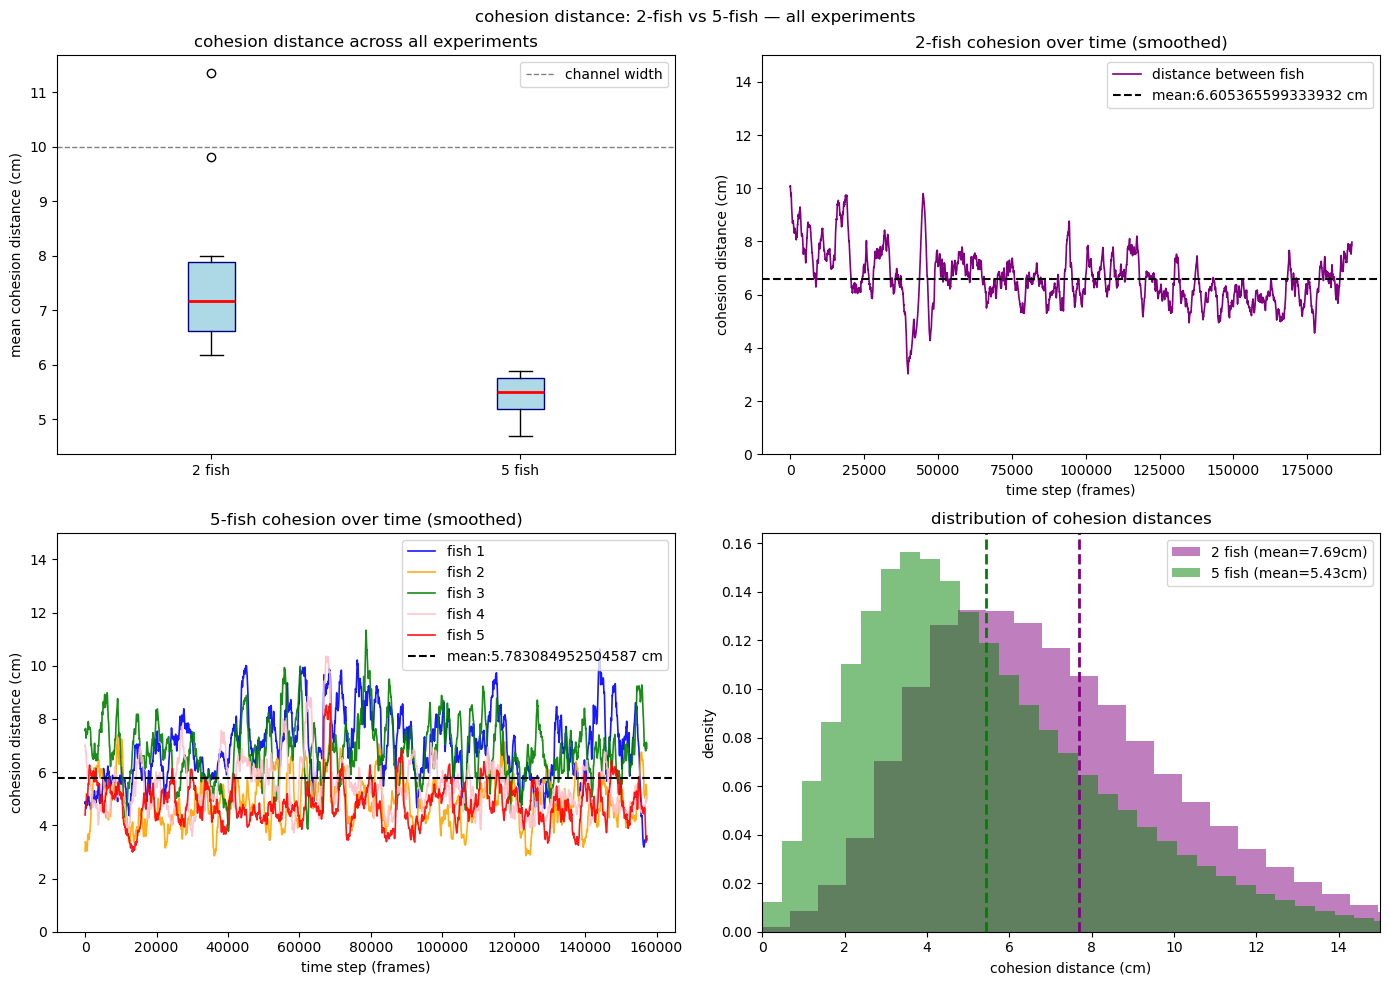

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
window = 2000

all_means_2fish = [np.nanmean(results_2fish[i][0] * mm_to_cm) for i in range(len(results_2fish))]
all_means_5fish = [np.nanmean(results_5fish[i][0] * mm_to_cm) for i in range(len(results_5fish))]


axes[0, 0].boxplot(
    [all_means_2fish, all_means_5fish],
    labels=['2 fish', '5 fish'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='navy'),
    medianprops=dict(color='red', lw=2)
)
axes[0, 0].set_title('cohesion distance across all experiments')
axes[0, 0].set_ylabel('mean cohesion distance (cm)')
axes[0, 0].axhline(y=10, color='gray', linestyle='--', lw=1, label='channel width')
axes[0, 0].legend()

colours_5 = ['blue', 'orange', 'green', 'pink', 'red']

smoothed_2 = pd.Series(cd_2_cm[:, 0]).rolling(window=window, center=True, min_periods=1).mean()
axes[0, 1].plot(smoothed_2, color='purple', lw=1.2, label='distance between fish')
axes[0, 1].axhline(y=np.nanmean(cd_2_cm), color='black', linestyle='--', lw=1.5,
                   label=f'mean:{np.nanmean(cd_2_cm)} cm')
axes[0, 1].set_title('2-fish cohesion over time (smoothed)')
axes[0, 1].set_xlabel('time step (frames)')
axes[0, 1].set_ylabel('cohesion distance (cm)')
axes[0, 1].set_ylim(0, 15)
axes[0, 1].legend()

for f in range(5):
    smoothed_5 = pd.Series(cd_5_cm[:, f]).rolling(window=window, center=True, min_periods=1).mean()
    axes[1, 0].plot(smoothed_5, color=colours_5[f], lw=1.2, label=f'fish {f+1}', alpha=0.9)
axes[1, 0].axhline(y=np.nanmean(cd_5_cm), color='black', linestyle='--', lw=1.5,
                   label=f'mean:{np.nanmean(cd_5_cm)} cm')
axes[1, 0].set_title('5-fish cohesion over time (smoothed)')
axes[1, 0].set_xlabel('time step (frames)')
axes[1, 0].set_ylabel('cohesion distance (cm)')
axes[1, 0].set_ylim(0, 15)
axes[1, 0].legend()

all_cd_2 = np.concatenate([results_2fish[i][0].flatten() * mm_to_cm 
                            for i in range(len(results_2fish))])
all_cd_5 = np.concatenate([results_5fish[i][0].flatten() * mm_to_cm 
                            for i in range(len(results_5fish))])

all_cd_2 = all_cd_2[~np.isnan(all_cd_2)]
all_cd_5 = all_cd_5[~np.isnan(all_cd_5)]

axes[1, 1].hist(all_cd_2, bins=100, alpha=0.5, color='purple', 
                label=f'2 fish (mean={np.nanmean(all_cd_2):.2f}cm)', density=True)
axes[1, 1].hist(all_cd_5, bins=100, alpha=0.5, color='green',
                label=f'5 fish (mean={np.nanmean(all_cd_5):.2f}cm)', density=True)
axes[1, 1].axvline(x=np.nanmean(all_cd_2), color='purple', linestyle='--', lw=2)
axes[1, 1].axvline(x=np.nanmean(all_cd_5), color='green', linestyle='--', lw=2)
axes[1, 1].set_title('distribution of cohesion distances')
axes[1, 1].set_xlabel('cohesion distance (cm)')
axes[1, 1].set_ylabel('density')
axes[1, 1].set_xlim(0, 15)
axes[1, 1].legend()

plt.suptitle('cohesion distance: 2-fish vs 5-fish — all experiments')
plt.tight_layout()
plt.show()

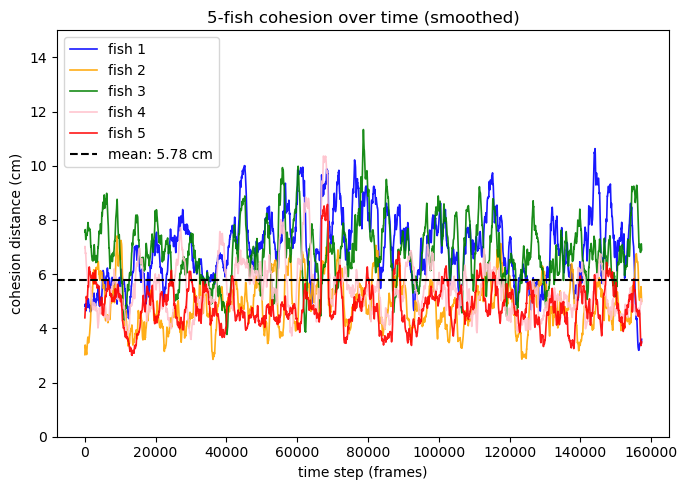

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

colours_5 = ['blue', 'orange', 'green', 'pink', 'red']
window = 2000

for f in range(5):
    smoothed_5 = pd.Series(cd_5_cm[:, f]).rolling(window=window, center=True, min_periods=1).mean()
    ax.plot(smoothed_5, color=colours_5[f], lw=1.2, label=f'fish {f+1}', alpha=0.9)

ax.axhline(y=np.nanmean(cd_5_cm), color='black', linestyle='--', lw=1.5,
           label=f'mean: {np.nanmean(cd_5_cm):.2f} cm')
ax.set_title('5-fish cohesion over time (smoothed)')
ax.set_xlabel('time step (frames)')
ax.set_ylabel('cohesion distance (cm)')
ax.set_ylim(0, 15)
ax.legend()

plt.tight_layout()
plt.savefig('5fish_cohesion_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
def calculate_c(df, n_fish, fps=50):
    ''' 
    calculates c, the measure of how actively each fish is moving towards
    the centre of its neighbours
    '''
    # extracting x/y columns for all fish and dropping any rows containing NaN
    columns = [f'X{i}' for i in range(1, n_fish+1)] + [f'Y{i}' for i in range(1, n_fish+1)]
    df_clean = df[columns].dropna()

    # building dictionary of position arrays per fish
    positions = {}
    for i in range(1, n_fish+1):
        positions[i] = df_clean[[f'X{i}', f'Y{i}']].values

    # stack into a single array shape (timesteps, n_fish, 2)
    pos_array = np.stack([positions[i] for i in range(1, n_fish+1)], axis=1)

    # getting the centre of neighbours of each fish
    centres, _ = centre_of_neighbours(pos_array)

    # vecotr pointing from each fish towards its neighbours' centre
    cohesion_vec  = centres - pos_array
    # distance from neighbours centre
    cohesion_dist = np.linalg.norm(cohesion_vec, axis=2)

    # replacing zeros with NaN to make sure i don't divide by 0
    dist_safe = np.where(cohesion_dist > 0, cohesion_dist, np.nan)
    # making unit vector pointing towards neihgbours centre
    unit_cohesion = cohesion_vec / dist_safe[:, :, np.newaxis]

    # calculating how much each fish moved between 2 consecutuve timesteps
    velocity = np.diff(pos_array, axis=0) 
    # converting to per second 
    velocity_per_sec = velocity * fps
    # projecting velocity onto unit conversion vector to get speed towards centre
    vel_towards = np.sum(velocity_per_sec * unit_cohesion[:-1, :, :], axis=2)

    # devide by cohesion distance to get c 
    c_values = vel_towards / cohesion_dist[:-1, :]

    # only keeping positive c values - neg means moving away from centre
    c_positive = np.where(c_values > 0, c_values, np.nan)

    # c for ecah individula fish overall
    for f in range(n_fish):
        print(f'fish {f+1}: c = {np.nanmean(c_positive[:, f])} /s')
    overall_c = np.nanmean(c_positive)
    print(f'overall c = {overall_c} /s')

    return c_positive, overall_c

# calculating c for 2 and 5 fish
c_results_2fish = [calculate_c(df, n_fish=2, fps=50) for df in dataframes_2fish]
c_results_5fish = [calculate_c(df, n_fish=5, fps=50) for df in dataframes_5fish]

# overall c value for each fish
c_grand_mean_2fish = np.nanmean([r[1] for r in c_results_2fish])
c_grand_mean_5fish = np.nanmean([r[1] for r in c_results_5fish])

print(f'2 fish: c = {c_grand_mean_2fish}')
print(f'5 fish: c = {c_grand_mean_5fish}')

fish 1: c = 1.6503534201447672 /s
fish 2: c = 1.5188855199332956 /s
overall c = 1.5688979282605224 /s
fish 1: c = 1.0998391765639774 /s
fish 2: c = 1.259663768005846 /s
overall c = 1.2013137120643416 /s
fish 1: c = 1.406655191760769 /s
fish 2: c = 1.716687047267775 /s
overall c = 1.5950742127388988 /s
fish 1: c = 2.1274075355838007 /s
fish 2: c = 2.0539095382361623 /s
overall c = 2.0721870212467577 /s
fish 1: c = 1.6260883414627754 /s
fish 2: c = 1.5315995566577656 /s
overall c = 1.5792097554911082 /s
fish 1: c = 1.7373153144196025 /s
fish 2: c = 1.479709991979372 /s
overall c = 1.6385133851780378 /s
fish 1: c = 0.7686730230241536 /s
fish 2: c = 1.000430956539877 /s
overall c = 0.922821302504417 /s
fish 1: c = 2.145511246860054 /s
fish 2: c = 2.6610522419295215 /s
overall c = 2.2691439671014018 /s
fish 1: c = 2.6574623458463487 /s
fish 2: c = 2.2610280320328036 /s
overall c = 2.5471538719466182 /s
fish 1: c = 1.6546973859751255 /s
fish 2: c = 2.0393858855745437 /s
overall c = 1.7215206

In [15]:
def calculate_coherence_range(df, n_fish, percentile=95):
    ''' 
    calculates the coherence range of the group
    '''
    from itertools import combinations

    # exctracts the x/y columns for all fish and drops any NaN rows
    columns = [f'X{i}' for i in range(1, n_fish+1)] + [f'Y{i}' for i in range(1, n_fish+1)]
    df_clean = df[columns].dropna()

    # builds a dictionary of position arrays per fish
    positions = {}
    for i in range(1, n_fish+1):
        positions[i] = df_clean[[f'X{i}', f'Y{i}']].values

    # stack into a single array shape (timesteps, n_fish, 2)
    pos_array = np.stack([positions[i] for i in range(1, n_fish+1)], axis=1)

    # claculating the distnace between every unique pair of fish at every timestep
    all_distances = []
    for i, j in combinations(range(n_fish), 2):
        diff = pos_array[:, i, :] - pos_array[:, j, :] # vector between pair
        dist = np.linalg.norm(diff, axis=1) # distance between pair
        all_distances.append(dist)

    # joinign all pair distnaces into 1 array and removing NaNs 
    all_distances = np.concatenate(all_distances)
    all_distances = all_distances[~np.isnan(all_distances)]

    print(f'mean pairwise distance= {np.mean(all_distances)} mm')
    print(f'median pairwise distance= {np.median(all_distances)} mm')
    print(f'95th percentile= {np.percentile(all_distances, 95)} mm')
    print(f'99th percentile= {np.percentile(all_distances, 99)} mm')
    print(f'max distance={np.max(all_distances)} mm')

    # coherence range = chosen percentile of all pairwise distnaces
    coherence_range = np.percentile(all_distances, percentile)
    return coherence_range, all_distances

ranges_2fish = [calculate_coherence_range(df, n_fish=2) for df in dataframes_2fish]
ranges_5fish = [calculate_coherence_range(df, n_fish=5) for df in dataframes_5fish]

range_2fish_mean = np.mean([r[0] for r in ranges_2fish])
range_5fish_mean = np.mean([r[0] for r in ranges_5fish])

print(f'2 fish coherence_range = {range_2fish_mean} mm')
print(f'5 fish coherence_range = {range_5fish_mean} mm')

mean pairwise distance= 113.43006321675212 mm
median pairwise distance= 58.70414452185771 mm
95th percentile= 547.120336318699 mm
99th percentile= 634.2360403345979 mm
max distance=679.7725338252864 mm
mean pairwise distance= 66.05365599333933 mm
median pairwise distance= 63.401872929844146 mm
95th percentile= 109.79947943252112 mm
99th percentile= 129.04502285973038 mm
max distance=220.34527335384894 mm
mean pairwise distance= 61.778590915048845 mm
median pairwise distance= 59.03142399362631 mm
95th percentile= 109.64760076915039 mm
99th percentile= 131.01145527236181 mm
max distance=349.58168659659503 mm
mean pairwise distance= 79.99299029213705 mm
median pairwise distance= 74.59507159803677 mm
95th percentile= 147.2564824846892 mm
99th percentile= 192.42513638024437 mm
max distance=314.52208497493467 mm
mean pairwise distance= 71.91404215443607 mm
median pairwise distance= 69.41496327979151 mm
95th percentile= 119.48926618600281 mm
99th percentile= 142.51382568217616 mm
max distance

In [ ]:
print('coherence_range per experiment (mm):')
print('\n2-fish:')
for i, r in enumerate(ranges_2fish):
    print(f'exp {i+1}: {r[0]:.1f} mm') # r[0] = coherence range

print('\n5-fish:')
for i, r in enumerate(ranges_5fish):
    print(f'  exp {i+1}: {r[0]:.1f} mm')

# Calculate mean excluding exp 1 for 2-fish 
ranges_2fish_no_outlier = [r[0] for r in ranges_2fish[1:]]  # exclude exp 1
ranges_5fish_all = [r[0] for r in ranges_5fish]

print(f'2-fish coherence_range (all):{np.mean([r[0] for r in ranges_2fish])} mm')
print(f'2-fish coherence_range (excluding exp 1):{np.mean(ranges_2fish_no_outlier)} mm')
print(f'5-fish coherence_range:{np.mean(ranges_5fish_all)} mm')

coherence_range per experiment (mm):

2-fish:
  exp 1: 547.1 mm
  exp 2: 109.8 mm
  exp 3: 109.6 mm
  exp 4: 147.3 mm
  exp 5: 119.5 mm
  exp 6: 112.1 mm
  exp 7: 111.0 mm
  exp 8: 148.6 mm
  exp 9: 131.9 mm
  exp 10: 152.4 mm

5-fish:
  exp 1: 151.3 mm
  exp 2: 124.0 mm
  exp 3: 140.6 mm
  exp 4: 155.1 mm
  exp 5: 128.2 mm
  exp 6: 144.6 mm
  exp 7: 166.6 mm
  exp 8: 123.6 mm
  exp 9: 149.0 mm
  exp 10: 149.3 mm
2-fish coherence_range (all):168.93332023581436 mm
2-fish coherence_range (excluding exp 1):126.9125406710494 mm
5-fish coherence_range:143.2374403082108 mm
